# Geometry and accessibility of annotation information

We examine representation shape and whether similar shape implies similar predictive usefulness. A shared linear probe separates encoder properties from the flexibility of the trained head.

## Introduction

The analysis supports the selection of heads for subsequent experiments. We keep prediction quality, reconstruction and geometry separate. Definitions and limitations are described in [METHODOLOGY.md](METHODOLOGY.md), and execution instructions in [README.md](README.md).

### Assumptions

The evaluated pixels come from the saved partitions of one campaign; the result does not measure transfer to a new patient or acquisition. A positive annotation is an observed P; a missing annotation does not confirm the absence of a molecule. The unit of model comparison is the seed, not the pixel; duplicate tasks for the same condition and seed do not increase the number of repetitions. Candidate selection uses validation, while test provides subsequent confirmation.

### Notation

$X \in \mathbb{R}^{N\times M}$ denotes TIC-normalized spectra, $\hat X$ reconstructions, $Y \in \{0,1\}^{N\times C}$ annotations, and $A$ label availability. $Z=\mathrm{Enc}(X)$ is the latent representation used by the head and decoder; $U=(Z-\beta)/\gamma$ reverses the affine transformation of the final LayerNorm. Evidence states follow N=0, P=1, U=2; **state U and representation $U$ are different objects**. $s$ denotes the positive ranking score. $r$ is an independent training repetition.


In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import display

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.visualization import predictive as plots

current = Path.cwd().resolve()
repository_root = next(path for path in (current, *current.parents) if (path / "pyproject.toml").is_file())
notebook_directory = repository_root / "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded"
settings_path = Path(os.environ.get("MSI_PREDICTIVE_SETTINGS", notebook_directory / "analysis_settings.yaml"))
settings = campaign.load_settings(settings_path)
RESULTS = notebook_directory / "part_6_latent_geometry_results"
RESULTS.mkdir(parents=True, exist_ok=True)


2026-09-08 10:28:23,975 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-08 10:28:23,978 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-08 10:28:24,316 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-08 10:28:24,318 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-08 10:28:24,319 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-08 10:28:24,320 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


## Dimension, radius, neighbourhoods and projections

### Methodology

#### Theoretical

Cov(Z) uses ddof=0. Effective rank is exp(-Σp_j log p_j), and participation ratio=(Σλ_j)²/Σλ_j². Zero variance is reported as collapse. Neighbourhoods use Euclidean distance, while Jaccard compares sets of known annotations.

#### Implementation

Z and U are analysed separately; the full split is used for variance and norms, and at most 512 shared rows for pairs and kNN. The same sample indices are used for every model. All pairs enter medians and histograms with 128 bins; exact distances can be reconstructed from the saved latent codes. PC1/PC2 are obtained by deterministic SVD of the sample for the given model. For U, coordinate sums and radius are also checked; LayerNorm constraints are not an arbitrary definition of success.

#### Figure descriptions

Violin: x=head, y=effective_rank, point=run. Curves: x=component number, y=eigenvalue; line=run. Distance histogram: x=Euclidean distance, y=density; each line is the full pair distribution of one run, and colour identifies the head family. PCA of one explicitly selected model: x=PC1, y=PC2; point=sample, colour identifies the head. The projection is descriptive only; axes are not aligned across models.


,metric,value,space,split,model_id,label,condition,repetition
0,trace,4.708294e+00,z,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
1,effective_rank,4.650801e+00,z,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
2,participation_ratio,3.492314e+00,z,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
3,collapsed,0.000000e+00,z,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
4,norm_mean,3.241529e+00,z,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
...,...,...,...,...,...,...,...,...
3115,row_sum_abs_max,9.087637e-07,u,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
3116,knn_annotation_jaccard,4.631870e-01,u,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
3117,pair_distance_median,3.200639e+00,u,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
3118,pair_cosine_median,4.877948e-01,u,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4


2026-09-08 10:28:31,874 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 4 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_6_latent_geometry_results.


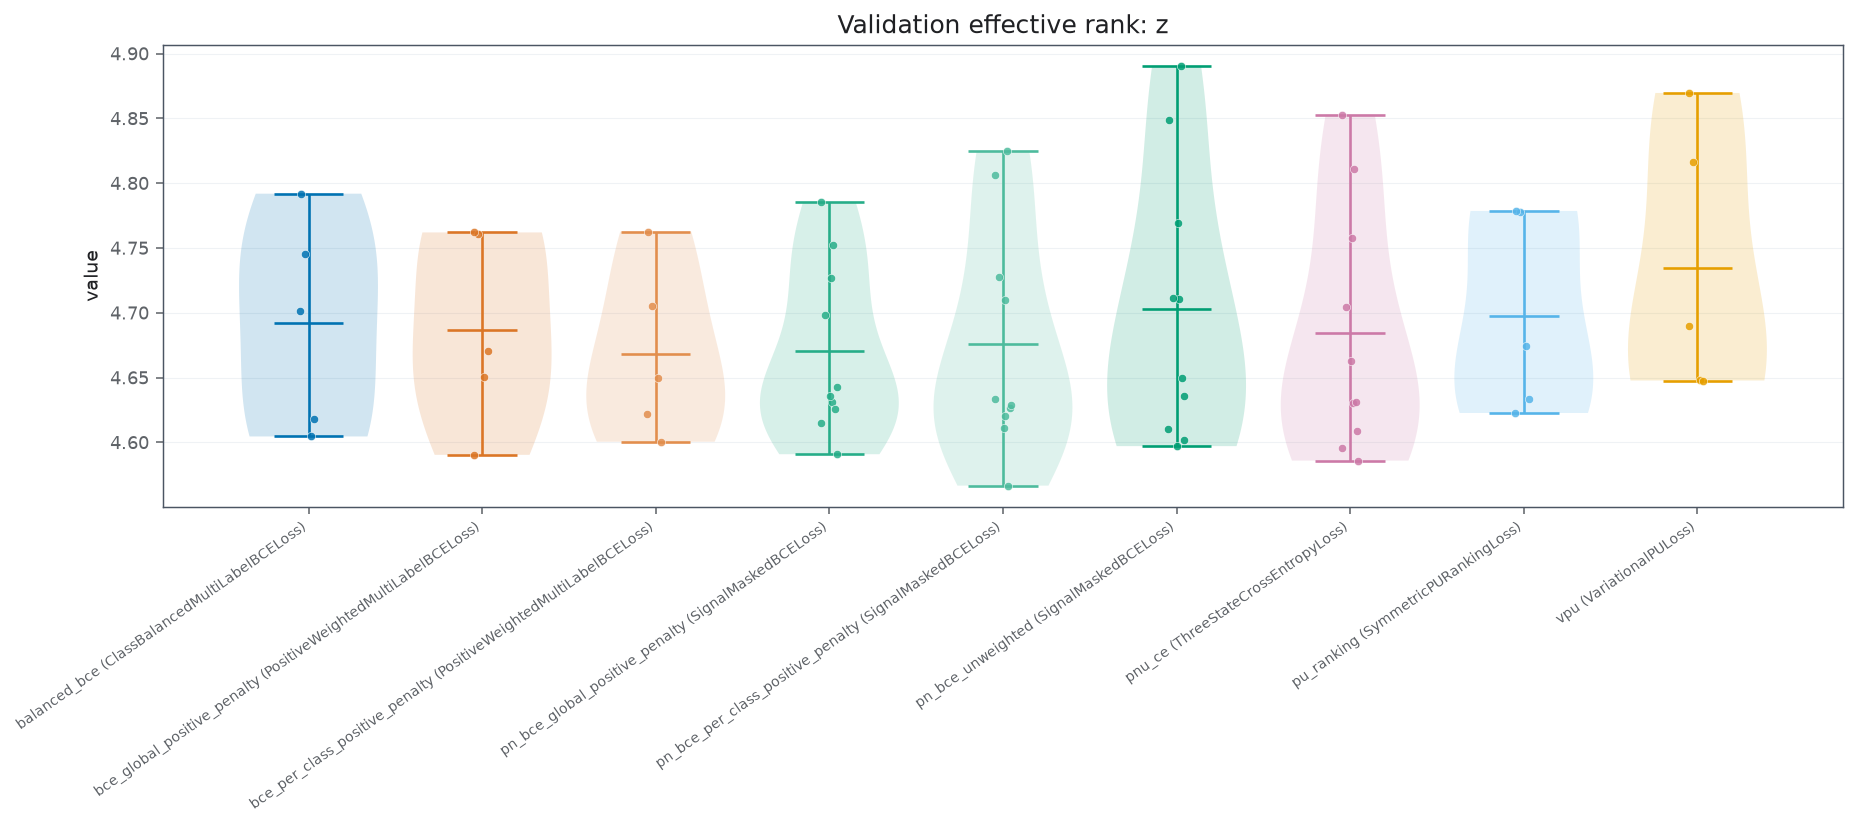

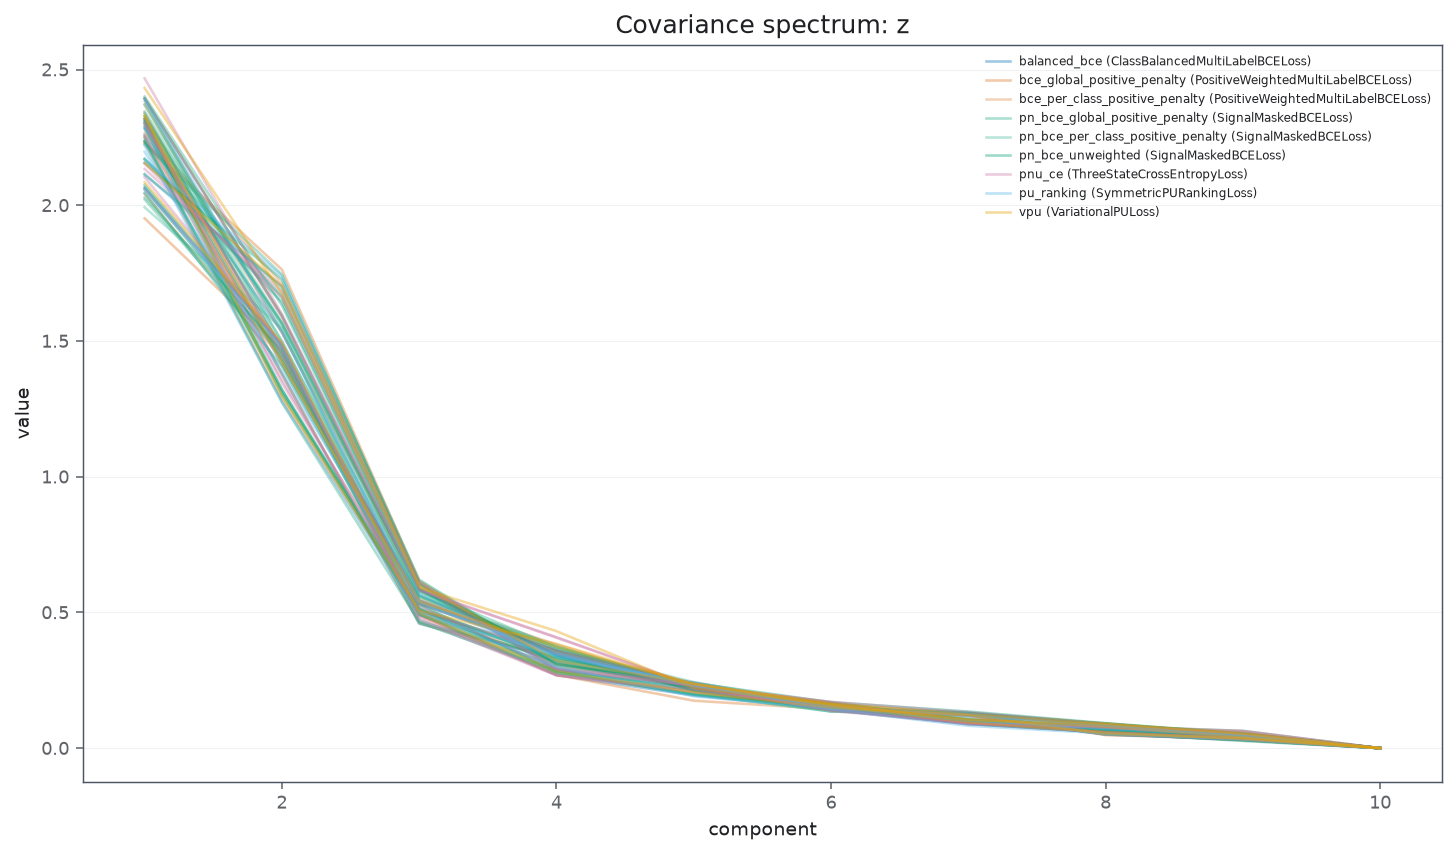

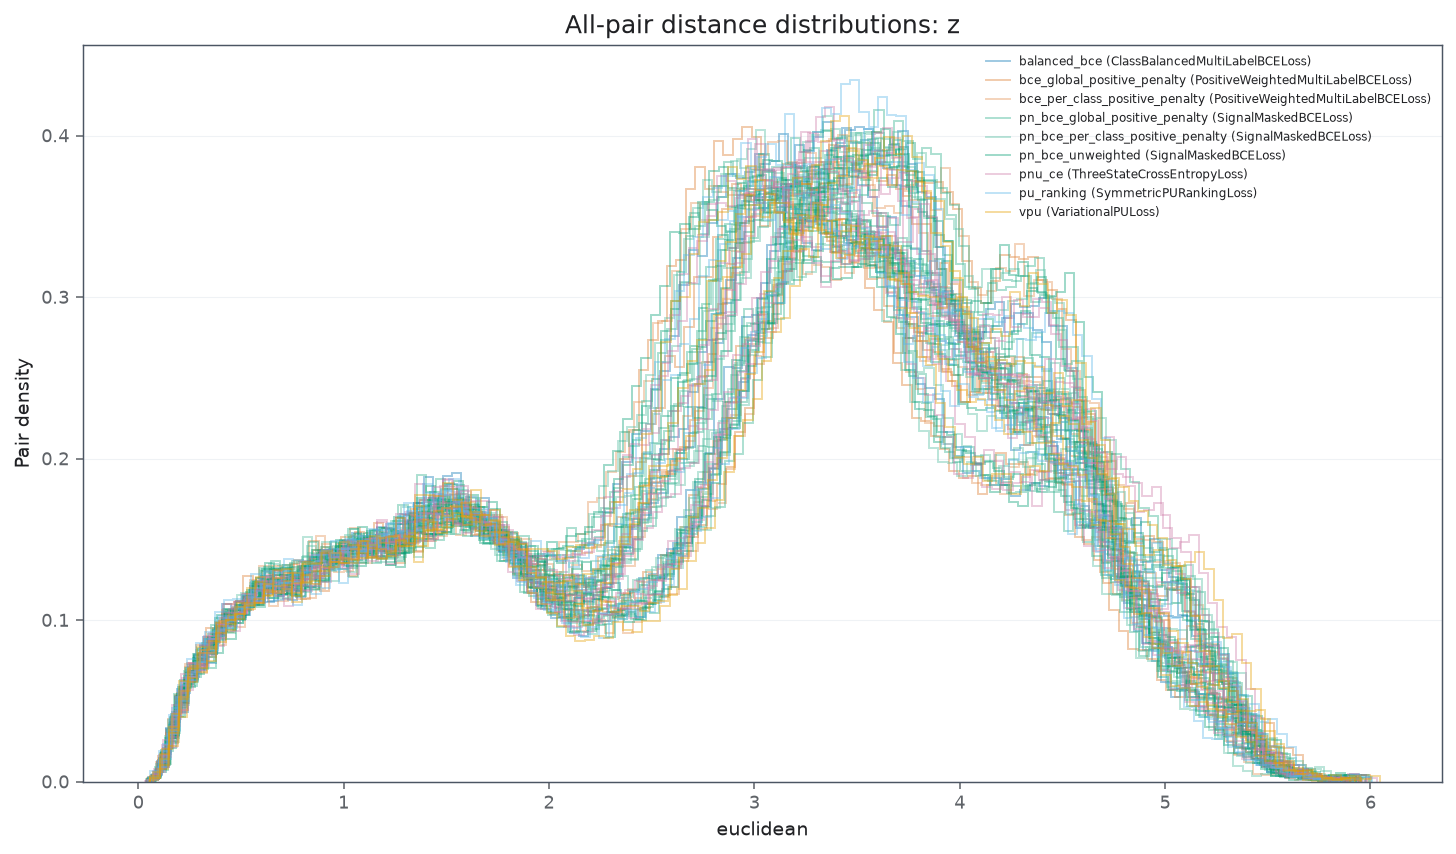

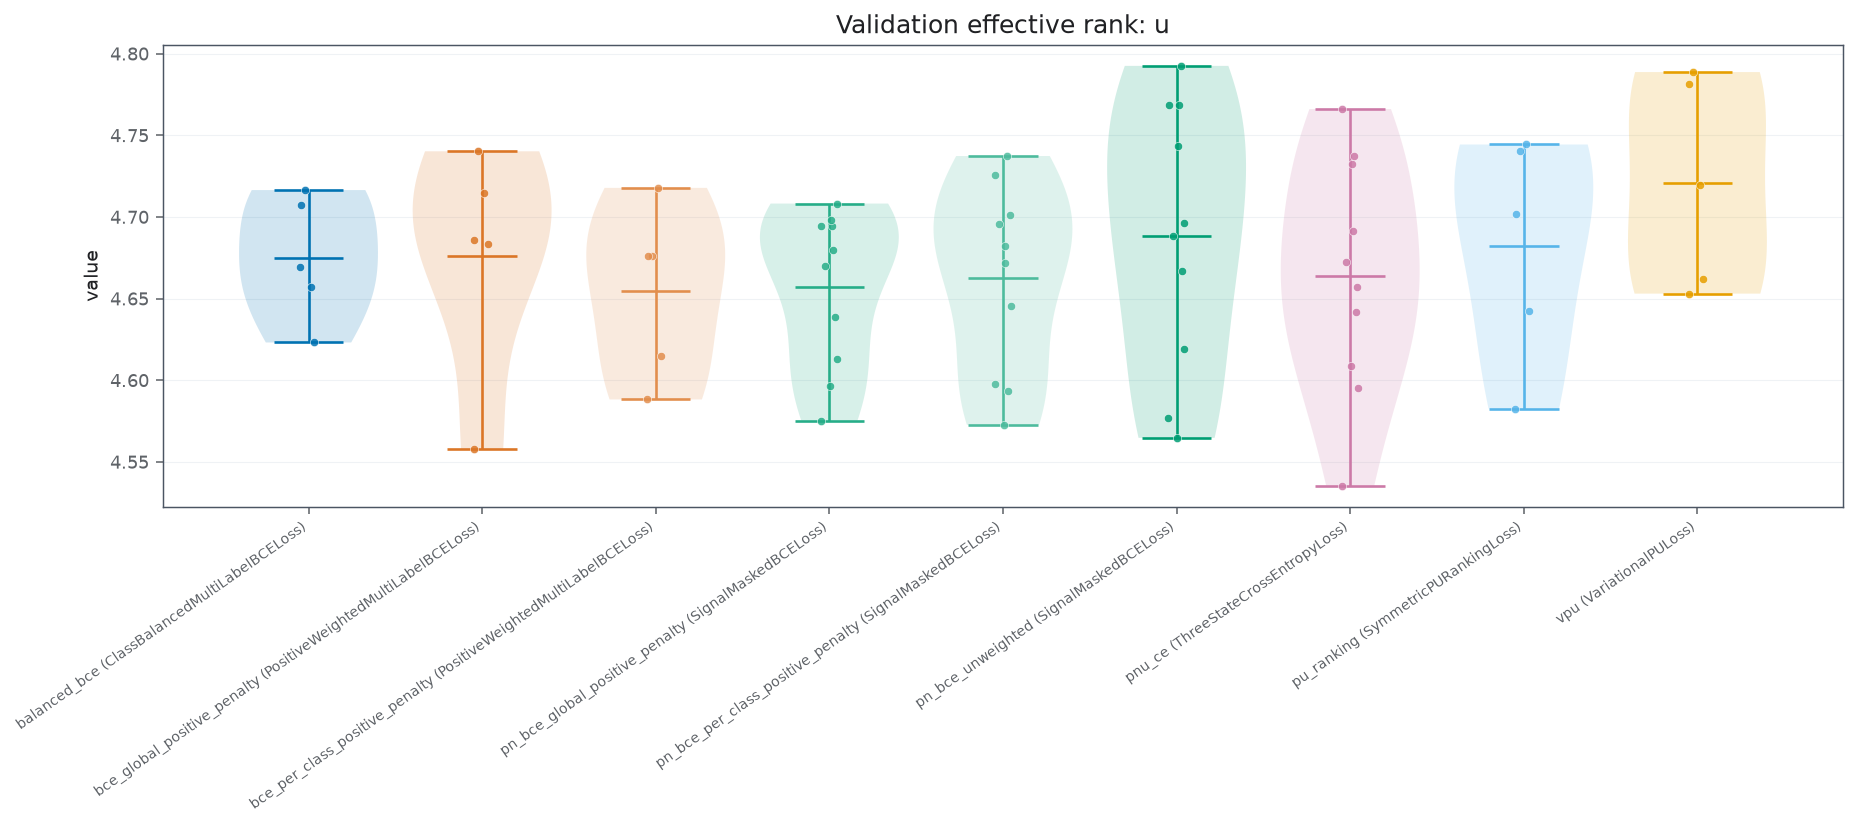

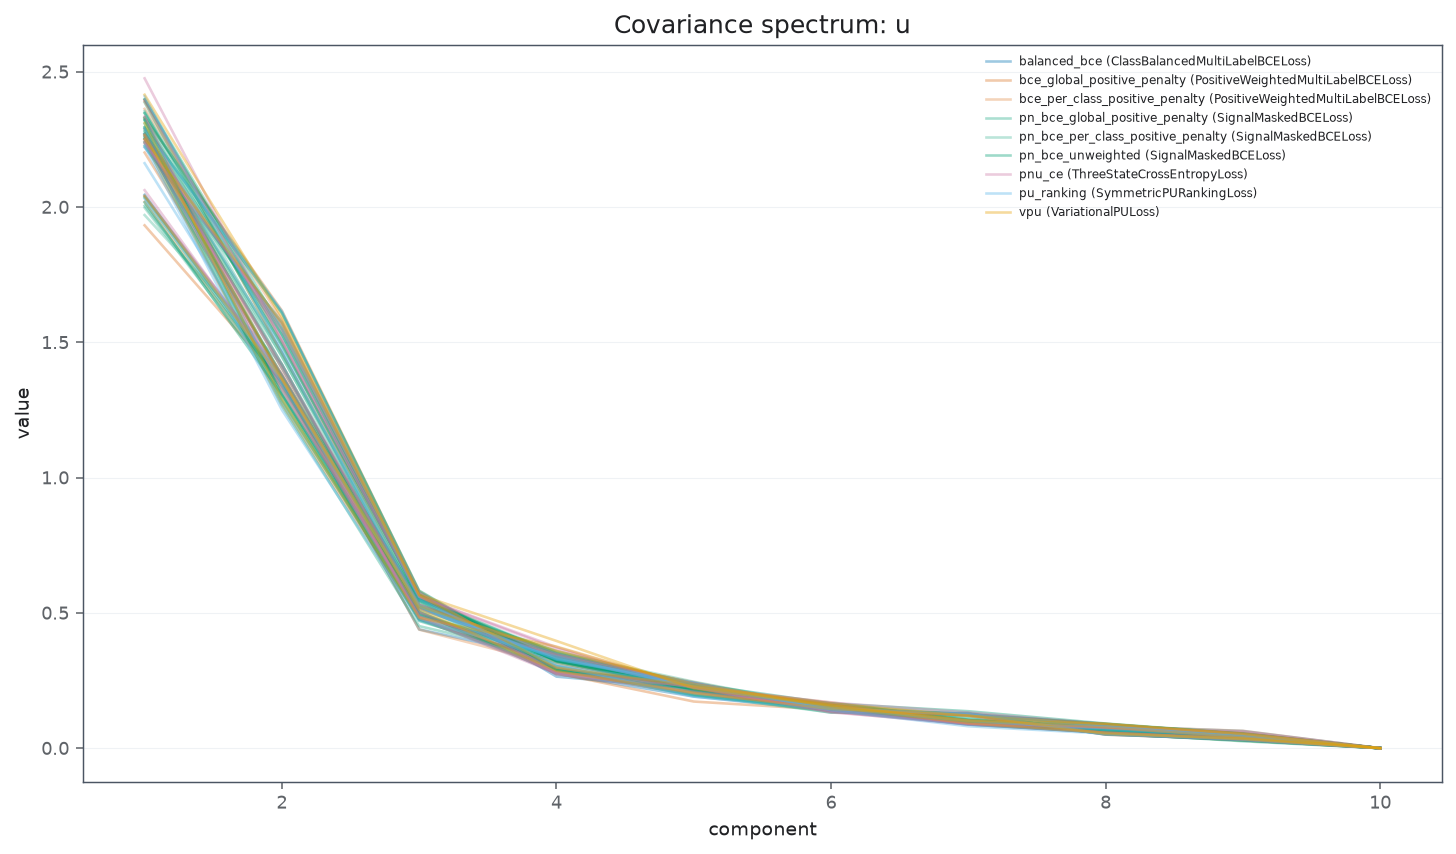

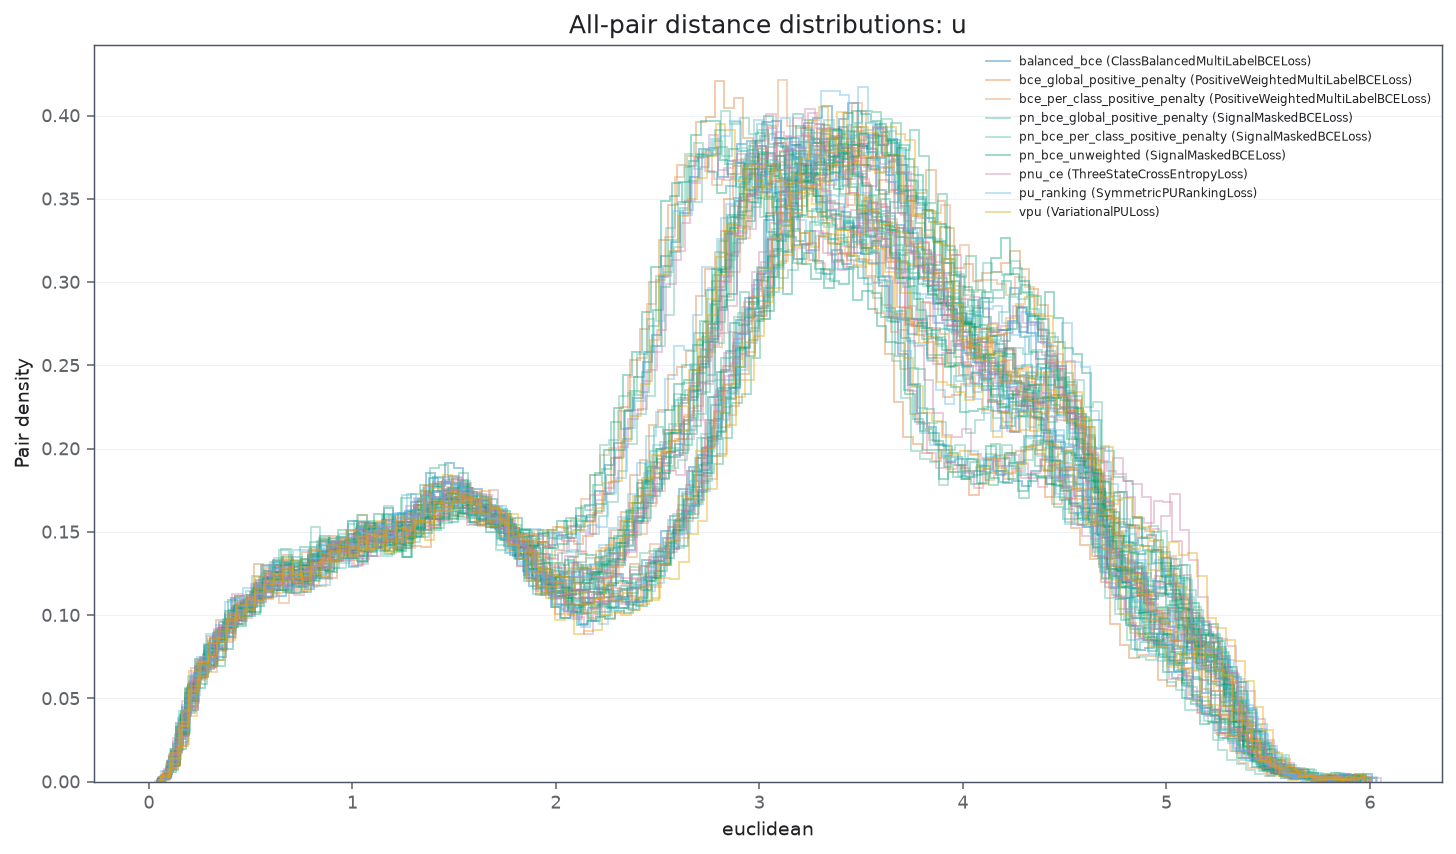

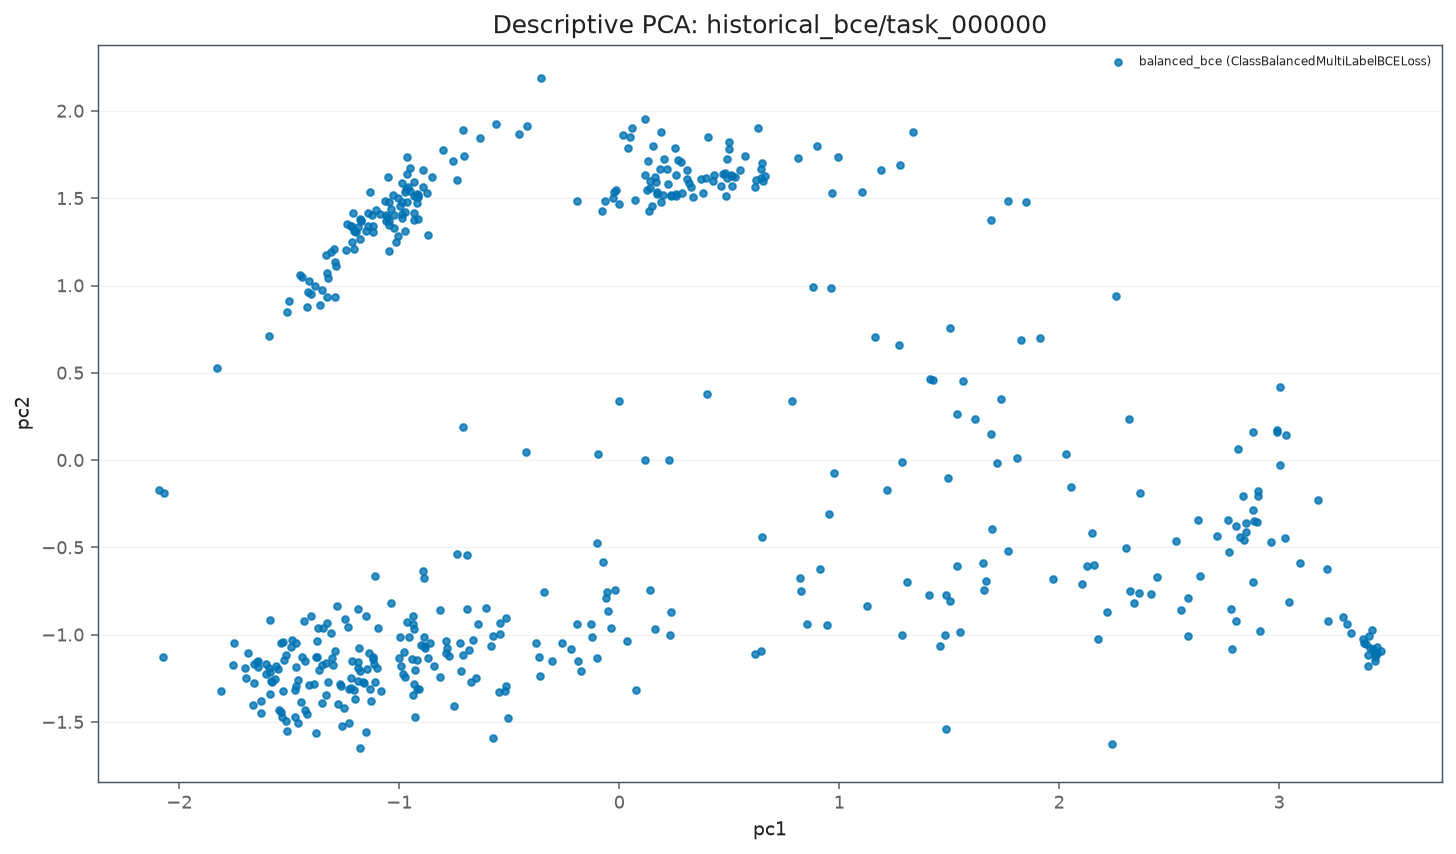

In [2]:
geometry = cache.load_table(settings, "geometry")
eigenvalues = cache.load_table(settings, "eigenvalues")
pixels = cache.load_table(settings, "geometry_pixels")
pairs = cache.load_table(settings, "geometry_pairs")
display(geometry)
for space in ["z", "u"]:
    plots.distributions(geometry.query("split == 'validation' and metric == 'effective_rank' and space == @space"), title=f"Validation effective rank: {space}").savefig(RESULTS / f"effective_rank_{space}.png")
    plots.trajectories(eigenvalues.query("split == 'validation' and space == @space"), x="component", title=f"Covariance spectrum: {space}").savefig(RESULTS / f"eigenvalues_{space}.png")
    plots.pair_histograms(pairs.query("split == 'validation' and space == @space and metric == 'euclidean'"), title=f"All-pair distance distributions: {space}").savefig(RESULTS / f"distances_{space}.png")
reports.save_tables(RESULTS, geometry=geometry, eigenvalues=eigenvalues, geometry_pixels=pixels, geometry_pairs=pairs)
example_model = sorted(pixels.model_id.unique())[0]
plots.scatter(pixels.query("model_id == @example_model and split == 'validation' and space == 'z'"), x="pc1", y="pc2", title=f"Descriptive PCA: {example_model}").savefig(RESULTS / "example_pca.png")

### Remarks

Results have not yet been computed for the target campaign.

### Notes


## Representation comparability and a shared linear probe

### Methodology

#### Theoretical

CKA = ||ZcᵀWc||²_F/(||ZcᵀZc||_F ||WcᵀWc||_F), where c denotes centring over rows. The probe minimizes mean squared annotation error + 0.01||B||²_F after standardizing features using train; the intercept is mean Y_train. This reads annotations from the latent representation; it is not a model of true molecular presence.

#### Implementation

CKA uses identical samples separately for validation/test and Z/U; comparisons carry same_condition/same_seed flags. The probe is fitted exclusively on train for each model, with the same fixed penalty. Its continuous score is evaluated with the same ranking metrics, without interpreting it as a probability.

#### Figure descriptions

Probe plot: x=head, y=validation AP; point=run. The CKA table allows comparison of variation across seeds of the same condition with variation across heads. Higher CKA means greater similarity, not better prediction.


2026-09-08 10:28:39,153 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_campaign:250 | Audited 65 model manifests across 2 sources.


,left_model,right_model,left,right,split,space,same_condition,same_seed,metric,value
0,predictive_initial/task_000000,predictive_initial/task_000001,bce_global_positive_penalty (PositiveWeightedM...,bce_global_positive_penalty (PositiveWeightedM...,validation,z,True,False,linear_cka,0.965993
1,predictive_initial/task_000000,predictive_initial/task_000001,bce_global_positive_penalty (PositiveWeightedM...,bce_global_positive_penalty (PositiveWeightedM...,validation,u,True,False,linear_cka,0.961224
2,predictive_initial/task_000000,predictive_initial/task_000001,bce_global_positive_penalty (PositiveWeightedM...,bce_global_positive_penalty (PositiveWeightedM...,test,z,True,False,linear_cka,0.966043
3,predictive_initial/task_000000,predictive_initial/task_000001,bce_global_positive_penalty (PositiveWeightedM...,bce_global_positive_penalty (PositiveWeightedM...,test,u,True,False,linear_cka,0.961738
4,predictive_initial/task_000000,predictive_initial/task_000002,bce_global_positive_penalty (PositiveWeightedM...,bce_global_positive_penalty (PositiveWeightedM...,validation,z,True,False,linear_cka,0.959747
...,...,...,...,...,...,...,...,...,...,...
8315,historical_bce/task_000002,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),balanced_bce (ClassBalancedMultiLabelBCELoss),test,u,True,False,linear_cka,0.974981
8316,historical_bce/task_000003,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),balanced_bce (ClassBalancedMultiLabelBCELoss),validation,z,True,False,linear_cka,0.983271
8317,historical_bce/task_000003,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),balanced_bce (ClassBalancedMultiLabelBCELoss),validation,u,True,False,linear_cka,0.985163
8318,historical_bce/task_000003,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),balanced_bce (ClassBalancedMultiLabelBCELoss),test,z,True,False,linear_cka,0.980488


,population,scope,metric,value,classes,split,model_id,label,condition,repetition
0,annotation_retrieval,train_supported,average_precision,0.529739,508,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
1,annotation_retrieval,train_supported,roc_auc,0.978109,508,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
2,annotation_retrieval,train_supported,ap_above_prevalence,0.480319,508,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
3,annotation_retrieval,rare,average_precision,0.054751,36,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
4,annotation_retrieval,rare,roc_auc,0.979377,36,validation,predictive_initial/task_000000,bce_global_positive_penalty (PositiveWeightedM...,061bcbfb8c04,0
...,...,...,...,...,...,...,...,...,...,...
3115,operational_pn,medium,roc_auc,0.970647,85,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
3116,operational_pn,medium,ap_above_prevalence,0.287567,85,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
3117,operational_pn,frequent,average_precision,0.767845,387,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4
3118,operational_pn,frequent,roc_auc,0.973900,387,test,historical_bce/task_000004,balanced_bce (ClassBalancedMultiLabelBCELoss),81fea4dad4ea,4


2026-09-08 10:28:48,555 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 2 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_6_latent_geometry_results.


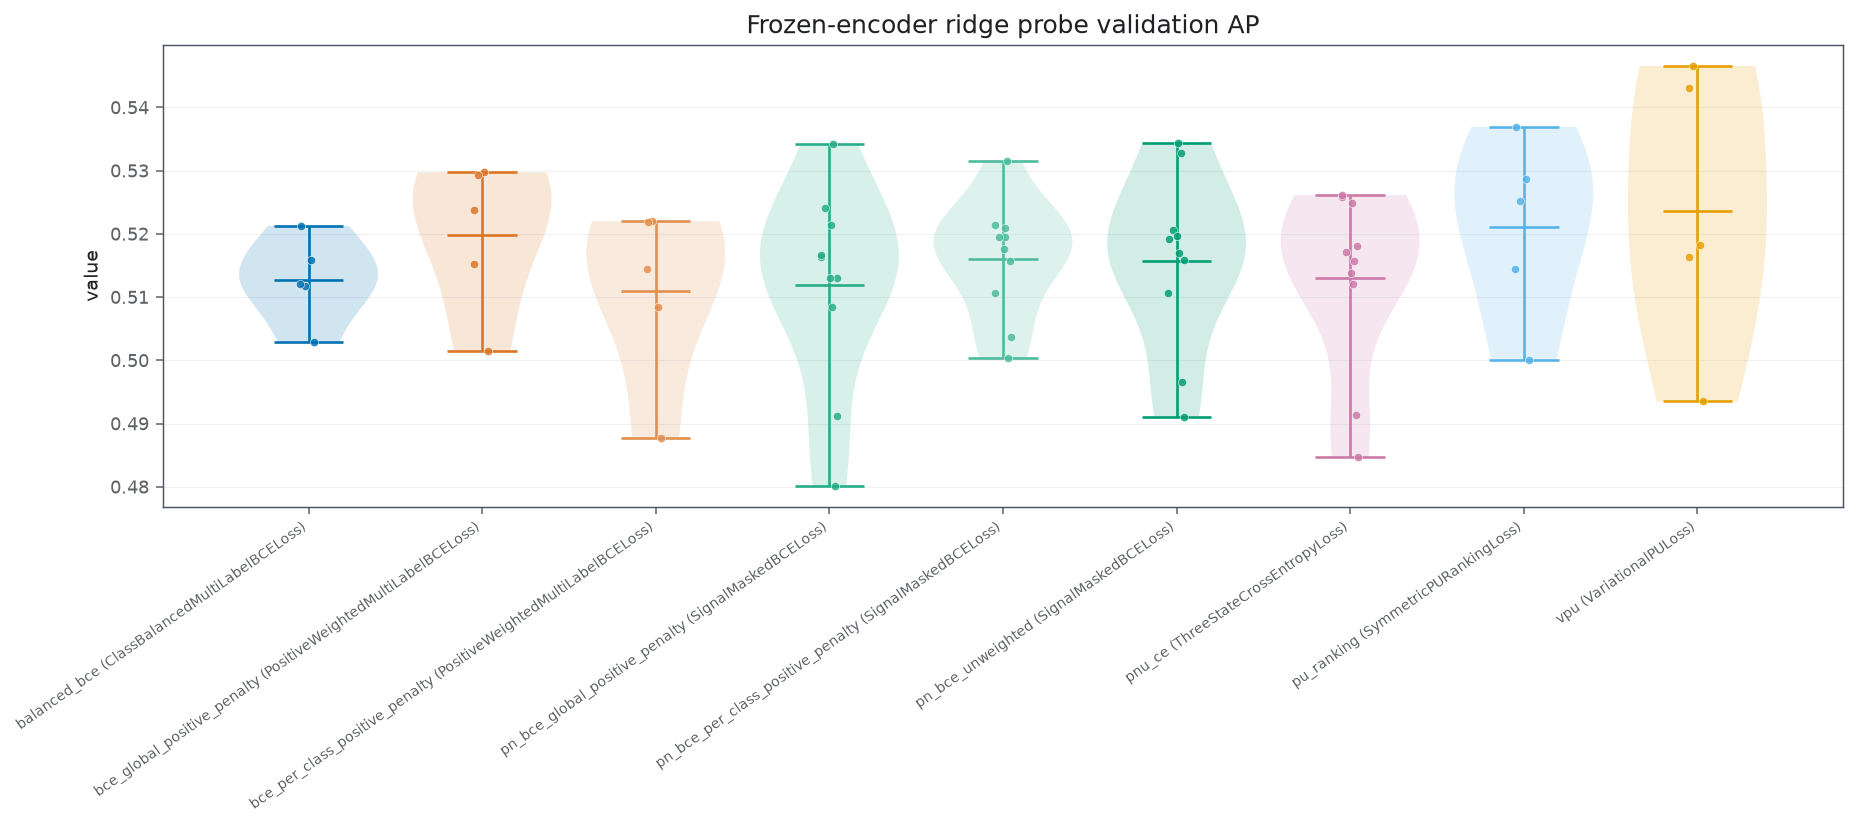

In [3]:
models, _ = campaign.inventory(settings)
similarity = reports.geometry_similarity(settings, models)
probe = cache.load_table(settings, "probe_prediction")
display(similarity)
display(probe)
plots.distributions(probe.query("split == 'validation' and scope == 'train_supported' and population == 'annotation_retrieval' and metric == 'average_precision'"), title="Frozen-encoder ridge probe validation AP").savefig(RESULTS / "probe_quality.png")
reports.save_tables(RESULTS, representation_similarity=similarity, probe_prediction=probe)

### Remarks

Geometry measured after training does not establish easier optimization. Jaccard depends on annotation frequency and incompleteness. A subsequent test should manipulate geometry or regularization with a fixed head and monitor the training trajectory.

### Notes


## Results / Summary

### LLM

An executable protocol and table exports have been prepared. Results from the target campaign are not yet available; this file does not contain an empirical conclusion that any head is superior. After execution, assess effect direction and magnitude, variation across seeds, completeness of pairs and limitations of the label definitions.

### Person
